In [1]:
print("all okay")


all okay


In [2]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model= "deepseek-r1-distill-llama-70b",
    temperature=0)

response = llm.invoke("what is length of wall of china")

In [3]:
response

AIMessage(content="<think>\nOkay, so I need to figure out the length of the Great Wall of China. I remember hearing that it's really long, but I'm not exactly sure how long. I think it's somewhere in the thousands of miles, but I'm not certain. Let me try to break this down.\n\nFirst, I know the Great Wall is a series of fortifications built across several Chinese dynasties. It wasn't built all at once, so maybe that's why the length can vary. I've heard different numbers before, like 13,000 miles or 21,000 kilometers. But I'm not sure which one is accurate.\n\nI should consider the sources of this information. Maybe some people measure it differently. I think the Chinese government did a survey a while back. I believe it was around 2012, and they measured the wall in a more precise way. They probably used modern technology like GPS to get a more accurate number.\n\nWait, so if the survey was in 2012, that's a reliable source. They might have included all the branches and sections, not

In [4]:
response.content

"<think>\nOkay, so I need to figure out the length of the Great Wall of China. I remember hearing that it's really long, but I'm not exactly sure how long. I think it's somewhere in the thousands of miles, but I'm not certain. Let me try to break this down.\n\nFirst, I know the Great Wall is a series of fortifications built across several Chinese dynasties. It wasn't built all at once, so maybe that's why the length can vary. I've heard different numbers before, like 13,000 miles or 21,000 kilometers. But I'm not sure which one is accurate.\n\nI should consider the sources of this information. Maybe some people measure it differently. I think the Chinese government did a survey a while back. I believe it was around 2012, and they measured the wall in a more precise way. They probably used modern technology like GPS to get a more accurate number.\n\nWait, so if the survey was in 2012, that's a reliable source. They might have included all the branches and sections, not just the main par

In [5]:
from langchain.tools import tool

### import custom tools

In [15]:
@tool
def add (a:int,b:int)->int:
    """
    Add two integers.

    Args:
        a (int) : The first integer.
        b (int) : The second integer.

    Returns:
        int : The sum of a and b .    
    """
    return a+b

@tool
def multiply(a:int,b:int) ->int:
    """
    Multiply two integer.

    Args:
        a (int) : The first integer.
        b (int) : The second integer.

        Returns:
            int :   The product of a and b.
    """
    return a*b


@tool
def divide(a:int, b:int)-> float:
    """ 
    Divide two numbers.

    Args: 
         a (int): the numerator
         b (int): the denominator(must not be 0)

    Returns:
        float :   The result of division.   
    """
    if b==0:
        raise ValueError("Denominator cannot be zero")

    return a /b

### importing the inbuild tool

In [10]:
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()

In [14]:
 search.invoke("what the lastest update on iphone 17 release ")

/Users/ebythomas/.local/lib/python3.13/site-packages/langchain_community/utilities/duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


"Jul 11, 2025 · Apple’s iPhone 17 is shaping up to be one of the most significant updates in recent years. With design overhauls, improved internals, and a shake-up in the model lineup, the 2025 … Dec 11, 2024 · Here's everything we've heard about the iPhone 17 range so far, including the rumored iPhone Air and when the next iPhone is coming out. Jul 24, 2025 · Planned for September 2025, the iPhone 17 models could feature larger display sizes, ProMotion across the lineup, Wi-Fi 7, and more. 2 days ago · •Look out for the iPhone 17 Pro launching in early September. • Apple may need to move the iPhone 17 Pro's logo. • Photos of the vapor chamber reportedly coming to the iPhone … Jul 2, 2025 · Apple’s iPhone 17 is poised to be a significant release, combining subtle design enhancements with strategic updates to maintain its position in the competitive smartphone …"

In [16]:
tools =[multiply,add,divide,search ]

In [18]:
 llm_with_tools = llm.bind_tools(tools)

In [20]:
response=llm_with_tools.invoke("HI")

In [22]:
response.content

'Hello! How can I assist you today?'

In [24]:
response.tool_calls

[]

In [25]:
response = llm_with_tools.invoke("what is 2+2?")

In [27]:
response.content

''

In [28]:
response.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': 'cckbyfdk8',
  'type': 'tool_call'}]

In [36]:
response =llm_with_tools.invoke("what is 10/2?")


In [37]:
response.content

''

In [38]:
response.tool_calls

[{'name': 'divide',
  'args': {'a': 10, 'b': 2},
  'id': '5q6ch1ebq',
  'type': 'tool_call'}]

In [51]:
response =llm_with_tools.invoke("what is a current age of the TATA Group?")

In [53]:
response


AIMessage(content="To find the current age of the TATA Group, I'll perform a search to determine its founding year.\n\n", additional_kwargs={'reasoning_content': "Okay, the user is asking about the current age of the TATA Group. I know that the TATA Group is a well-established conglomerate, but I'm not exactly sure of its founding year. I think it was founded in the late 19th century, maybe around the 1860s or 1870s. To get the exact year, I should look it up. Once I have the founding year, I can subtract that from the current year, 2023, to find out the age. So, I'll use the DuckDuckGo search tool to find when the TATA Group was founded.\n", 'tool_calls': [{'id': 'jp91fnw8e', 'function': {'arguments': '{"query":"TATA Group founding year"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 183, 'prompt_tokens': 410, 'total_tokens': 593, 'completion_time': 0.79643234, 'prompt_time': 0.033088056, 'queue_time': 0.210384981, 'tota

In [52]:
response.content



"To find the current age of the TATA Group, I'll perform a search to determine its founding year.\n\n"

In [54]:
response.tool_calls



[{'name': 'duckduckgo_search',
  'args': {'query': 'TATA Group founding year'},
  'id': 'jp91fnw8e',
  'type': 'tool_call'}]

In [69]:
# class MessagesState(TypedDict):
#     messages: Annotated[list[AnyMessage], add_messages]

In [70]:

SYSTEM_PROMPT="You are a helpful assistant tasked with using search and performing arithmetic on a set of inputs."

In [72]:
user_query=["tell me what is 2+2"]

In [73]:
[SYSTEM_PROMPT]+user_query

['You are a helpful assistant tasked with using search and performing arithmetic on a set of inputs.',
 'tell me what is 2+2']

In [89]:
def function_1(state:MessagesState):
    user_question = state["messages"]
    input_question = [SYSTEM_PROMPT]+user_question

    response = llm_with_tools.invoke(input_question)

    return {'messages':[response]}

In [55]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState, StateGraph, START, END

In [90]:
builder = StateGraph(MessagesState)

In [91]:
builder.add_node("llm_decision_step", function_1)

In [92]:
from langgraph.prebuilt import ToolNode

In [93]:
builder.add_node("tools", ToolNode(tools))

In [94]:
builder.add_edge(START,"llm_decision_step")

In [95]:
from langgraph.prebuilt import tools_condition

In [96]:
builder.add_conditional_edges("llm_decision_step",tools_condition
                              )
                              

In [97]:
builder.add_edge("tools","llm_decision_step")

In [98]:
react_graph = builder.compile()

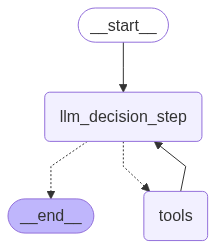

In [99]:
from IPython.display import Image, display
display(Image(react_graph.get_graph().draw_mermaid_png()))

In [100]:
message =[HumanMessage(content="what us 2 times of narendramodi's age ?")]

In [101]:
react_graph.invoke({"messages":message})

/Users/ebythomas/.local/lib/python3.13/site-packages/langchain_community/utilities/duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
/Users/ebythomas/.local/lib/python3.13/site-packages/langchain_community/utilities/duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


{'messages': [HumanMessage(content="what us 2 times of narendramodi's age ?", additional_kwargs={}, response_metadata={}, id='beff778c-47f1-45ba-a0b5-29ab154467ae'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, so the user is asking, "what us 2 times of narendramodi\'s age?" First, I need to understand what they\'re asking for. It seems like they want to find out twice the age of Narendra Modi. \n\nTo do this, I need to figure out Narendra Modi\'s current age. I don\'t have that information off the top of my head, so I should use the DuckDuckGo search tool to look it up. \n\nI\'ll call the duckduckgo_search function with the query "Narendra Modi age" to get the most accurate and up-to-date information. Once I have his age, I can then use the multiply function to calculate twice that number.\n\nSo, the steps are: \n1. Use duckduckgo_search to find Narendra Modi\'s age.\n2. Use the multiply function with his age and 2 as the arguments.\n', 'tool_calls': [{'id': 

In [102]:
message = [HumanMessage(content="How much is the net worth of Elon Musk, and divide it by 2?")]

In [103]:
react_graph.invoke({"messages":message})

/Users/ebythomas/.local/lib/python3.13/site-packages/langchain_community/utilities/duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


{'messages': [HumanMessage(content='How much is the net worth of Elon Musk, and divide it by 2?', additional_kwargs={}, response_metadata={}, id='d9b2162f-ae70-47be-9653-4bc18f7fe9a4'),
  AIMessage(content="First, I'll look up Elon Musk's current net worth.\n\n", additional_kwargs={'reasoning_content': "Alright, so the user is asking about Elon Musk's net worth and then dividing it by 2. First, I need to find the current net worth of Elon Musk. I remember that his net worth fluctuates a lot, especially with the stock prices of his companies like Tesla and SpaceX. I should use the DuckDuckGo tool to get the most recent figure.\n\nOnce I have the net worth, the next step is to divide it by 2. Since the user didn't specify the exact number, I'll have to wait for the search results to get the precise value. After obtaining the number, I'll use the divide function to split it by 2. \n\nI should make sure that the number I get from the search is accurate and up-to-date because net worth can 

In [104]:
message = [HumanMessage(content="What is the speed of light in m/s and multiply it by 10?")]

In [105]:
response= react_graph.invoke({"messages":message})

In [106]:
response['messages'][-1].content

'The speed of light in meters per second is 299,792,000 m/s. When multiplied by 10, the result is 2,997,920,000 m/s.'

In [109]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the speed of light in m/s and multiply it by 10?
================================== Ai Message ==================================

The speed of light is approximately 299,792,000 meters per second. When multiplied by 10, the result is 2,997,920,000 meters per second.
Tool Calls:
  multiply (akg4aqdtx)
 Call ID: akg4aqdtx
  Args:
    a: 299792000
    b: 10
================================= Tool Message =================================
Name: multiply

2997920000
================================== Ai Message ==================================

The speed of light in meters per second is 299,792,000 m/s. When multiplied by 10, the result is 2,997,920,000 m/s.


In [112]:
import yfinance as yf

In [113]:
@tool
def get_stock_price(ticker:str)->str:
    """
    Fetches the previous closing price of a given stock ticker from Yahoo Finance.

    Args:
        ticker (str): The stock ticker symbol (e.g., 'AAPL', 'TSLA', 'NIFTY.BO').

    Returns:
        str: A message with the stock's previous closing price.
    """
    try:
        stock = yf.Ticker(ticker)
        price = stock.info.get('previousClose')
        if price is None:
            return f"Could not fetch price for ticker '{ticker}'."
        return f"The last closing price of {ticker.upper()} was ${price:.2f}."
    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"
     
    

In [114]:
get_stock_price.invoke("AAPL")

'The last closing price of AAPL was $211.27.'

In [115]:
tools

[StructuredTool(name='multiply', description='Multiply two integer.\n\nArgs:\n    a (int) : The first integer.\n    b (int) : The second integer.\n\n    Returns:\n        int :   The product of a and b.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x119334680>),
 StructuredTool(name='add', description='Add two integers.\n\nArgs:\n    a (int) : The first integer.\n    b (int) : The second integer.\n\nReturns:\n    int : The sum of a and b .', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x119870b80>),
 StructuredTool(name='divide', description='Divide two numbers.\n\nArgs: \n     a (int): the numerator\n     b (int): the denominator(must not be 0)\n\nReturns:\n    float :   The result of division.', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<function divide at 0x1191cf100>),
 DuckDuckGoSearchRun(api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', max

In [116]:
tools =[multiply,add,divide,search,get_stock_price]

In [117]:
llm_with_tools=llm.bind_tools(tools)

In [118]:
response = llm_with_tools.invoke("can you give latest stock price of apple")

In [120]:
response.content

''

In [121]:
response.tool_calls

[{'name': 'get_stock_price',
  'args': {'ticker': 'AAPL'},
  'id': 'ntqex66ze',
  'type': 'tool_call'}]

In [139]:
SYSTEM_PROMPT = SystemMessage(
    content="You are a helpful assistant tasked with using search, the yahoo finance tool and performing arithmetic on a set of inputs."
)
def function_1(state:MessagesState):
    
    user_question=state["messages"]
    
    input_question = [SYSTEM_PROMPT]+user_question
    
    response = llm_with_tools.invoke(input_question)
    
    return {
        "messages":[response]
    }

In [140]:
workflow = StateGraph(MessagesState)
workflow.add_node("llm_decision_step", function_1)
workflow.add_node("tools", ToolNode(tools))
workflow.add_edge(START, "llm_decision_step")
workflow.add_conditional_edges(
    "llm_decision_step",
    tools_condition,
)
workflow.add_edge("tools", "llm_decision_step")
react_graph2 = workflow.compile()

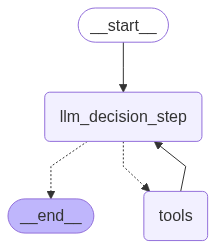

In [141]:

display(Image(react_graph2.get_graph(xray=True).draw_mermaid_png()))

In [144]:
messages = [HumanMessage(content="add 1000 in the current stock price of Apple.")]
messages = react_graph2.invoke({"messages": messages})

In [145]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

add 1000 in the current stock price of Apple.
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (ah3x9nkdq)
 Call ID: ah3x9nkdq
  Args:
    ticker: AAPL
================================= Tool Message =================================
Name: get_stock_price

The last closing price of AAPL was $211.27.
================================== Ai Message ==================================

The result of adding 1000 to the current stock price of Apple (AAPL) is:

**1000 + 211.27 = 1211.27**
Tool Calls:
  add (ge6e5tpy8)
 Call ID: ge6e5tpy8
  Args:
    a: 1000
    b: 211
================================= Tool Message =================================
Name: add

1211
================================== Ai Message ==================================

The sum of 1000 and the current stock price of Apple (211.27) is **1211**.


In [147]:
messages = [HumanMessage(content="can you give me the current stock price of Apple with the latest news of the Apple.")]
messages = react_graph2.invoke({"messages": messages})

GraphRecursionError: Recursion limit of 25 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/GRAPH_RECURSION_LIMIT

In [ ]:
for m in messages['messages']:
    m.pretty_print()

TypeError: list indices must be integers or slices, not str